<a href="https://colab.research.google.com/github/mbenedicto99/artificial_intelligence/blob/master/Linguistica_Clinica.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Documentação do Notebook:
# Classificação de Textos para Detecção de Doença de Alzheimer
## Autor: Marcos de Benedicto
## Data : 25/mar/26
=================================

Este notebook tem como objetivo construir e avaliar um modelo de classificação de texto para distinguir entre narrativas de indivíduos com Doença de Alzheimer (AD), Comprometimento Cognitivo Leve (MCI) e um grupo de Controle. O processo envolve o carregamento de dados, uma série de etapas de pré-processamento de texto, extração de características e, finalmente, o treinamento e avaliação de um classificador de aprendizado de máquina.

## 1. Carregamento e Pré-processamento dos Dados

### 1.1. Descompactação do Corpus

O primeiro passo consiste em descompactar o arquivo `Cinderella.zip` que contém os dados textuais. O conteúdo é extraído para a pasta `/content/Cinderella_Corpus`.

### 1.2. Carregamento dos Dados

A função `load_data` é utilizada para carregar os arquivos `.txt` das pastas extraídas (`ADs`, `MCIs`, `Controls`) em um DataFrame pandas. Cada documento é lido, e seu texto e a classe correspondente são armazenados. Foi feito um ajuste no caminho base para lidar com um diretório `Cinderella` aninhado após a descompactação, garantindo que os dados sejam carregados corretamente.

### 1.3. Divisão de Sentenças

Os textos são divididos em sentenças. Conforme a descrição do problema, as sentenças são tokenizadas por sentenças, todas elas terminando em um ponto final separado da última palavra por um espaço em branco. Isso permite usar `. ` como delimitador para a divisão.

### 1.4. Tokenização de Palavras

As sentenças são então tokenizadas em palavras usando o `word_tokenize` da biblioteca NLTK para o idioma português. Isso transforma cada sentença em uma lista de palavras individuais. O corpus `punkt` do NLTK é baixado caso não esteja disponível.

### 1.5. Remoção de Stopwords

Para reduzir o ruído e focar nas palavras mais significativas, stopwords (palavras comuns como artigos, preposições, etc.) em português são removidas das sentenças tokenizadas. O corpus `stopwords` do NLTK é baixado caso não esteja disponível.

### 1.6. Stemização

É aplicada a stemização às palavras restantes usando o `RSLPStemmer` do NLTK. A stemização reduz as palavras à sua raiz (radical), o que ajuda a agrupar diferentes formas de uma mesma palavra (ex: "correndo", "corre" -> "corr"). O corpus `rslp` do NLTK é baixado caso não esteja disponível.

### 1.7. Consolidação do Texto Processado

Após todas as etapas de pré-processamento, as palavras stemizadas de cada documento são reunidas em uma única string (`processed_text`). Esta coluna será usada para a vetorização e subsequente treinamento do modelo.

## 2. Preparação para o Modelo

### 2.1. Divisão do Conjunto de Dados

O conjunto de dados é dividido em conjuntos de treinamento (80%) e teste (20%) usando `train_test_split` do `sklearn.model_selection`. A divisão é estratificada (`stratify=y`) para garantir que a proporção de classes (AD, MCI, Controls) seja mantida em ambos os conjuntos, o que é crucial para conjuntos de dados desbalanceados ou pequenos.

### 2.2. Vetorização TF-IDF (Term Frequency-Inverse Document Frequency)

**O que é?**
TF-IDF é uma técnica estatística que reflete a importância de uma palavra em um documento em relação a um corpus (conjunto de documentos). É amplamente utilizada na recuperação de informação e mineração de texto.

**Como funciona?**
*   **Term Frequency (TF):** Mede a frequência com que uma palavra aparece em um documento. Quanto mais uma palavra aparece, maior sua TF.
    
*   **Inverse Document Frequency (IDF):** Mede o quão rara ou comum uma palavra é em todo o corpus. Palavras que aparecem em muitos documentos (como "o", "a", "de") terão um IDF baixo, enquanto palavras que aparecem em poucos documentos terão um IDF alto. Isso ajuda a diminuir o peso de palavras muito comuns que não carregam muita informação.
    
*   **TF-IDF:** É o produto de TF e IDF. Uma pontuação TF-IDF alta significa que a palavra é frequente em um documento específico, mas rara em todo o corpus, tornando-a um bom descritor para aquele documento.

**Por que usamos aqui?**
Para converter o texto pré-processado (tokens stemizados) em um formato numérico que os algoritmos de aprendizado de máquina podem entender e processar. `max_features=5000` limita o vocabulário a 5000 palavras mais informativas, reduzindo a dimensionalidade e o ruído.

## 3. Treinamento e Avaliação do Modelo

### 3.1. Classificador Multinomial Naive Bayes

**O que é?**
Multinomial Naive Bayes é um algoritmo de classificação probabilístico baseado no Teorema de Bayes, com uma suposição de "ingenuidade" (naive) de independência entre os preditores (as palavras neste caso).

**Como funciona?**
Ele calcula a probabilidade de um documento pertencer a uma classe específica (AD, MCI, Controls) dada a frequência das palavras no documento. A "ingenuidade" reside no pressuposto de que a presença de uma palavra em um documento é independente da presença de qualquer outra palavra, dada a classe do documento.

**Por que usamos aqui?**
É particularmente adequado para classificação de texto, onde as características são frequentemente contagens de palavras ou frequências (como no TF-IDF). É um modelo simples, rápido de treinar e frequentemente eficaz para tarefas de classificação de texto.

O modelo é treinado com os dados TF-IDF do conjunto de treinamento (`X_train_tfidf`) e as classes correspondentes (`y_train`).

### 3.2. Métricas de Avaliação do Modelo

Para avaliar o desempenho do nosso modelo, utilizamos várias métricas:

*   **Acurácia (Accuracy):** A proporção de previsões corretas (verdadeiros positivos + verdadeiros negativos) em relação ao número total de casos. É uma medida geral do desempenho do modelo.
    
*   **Precisão (Precision):** Para uma classe específica, é a proporção de verdadeiros positivos em relação ao total de previsões positivas (verdadeiros positivos + falsos positivos). Responde à pergunta: "Das vezes que o modelo previu esta classe, quantas estavam corretas?"
    
*   **Recall (Cobertura):** Para uma classe específica, é a proporção de verdadeiros positivos em relação ao total de casos reais dessa classe (verdadeiros positivos + falsos negativos). Responde à pergunta: "Das vezes que esta classe realmente ocorreu, quantas o modelo conseguiu identificar?"
    
*   **F1-Score:** É a média harmônica da Precisão e do Recall. É uma métrica útil quando há um desequilíbrio entre as classes ou quando falsos positivos e falsos negativos têm custos diferentes. Um F1-Score alto indica que o modelo tem bom Recall e boa Precisão.

**`average='weighted'`:** Indica que as métricas são calculadas para cada classe e então ponderadas pela proporção de cada classe no conjunto de dados (o número de instâncias reais para cada rótulo) para dar uma média geral. Isso é importante em conjuntos de dados desbalanceados.

*   **Matriz de Confusão:** Uma tabela que visualiza o desempenho de um algoritmo de classificação. Cada linha da matriz representa as instâncias em uma classe real, enquanto cada coluna representa as instâncias em uma classe prevista. Isso nos ajuda a entender quais classes o modelo está confundindo.

O modelo é avaliado usando os dados de teste (`X_test_tfidf`), e as previsões (`y_pred`) são comparadas com as classes reais (`y_test`). Um relatório de classificação detalhado e uma matriz de confusão visual são gerados para analisar o desempenho do modelo, incluindo a identificação de misclassificações entre as classes AD e MCI.

In [40]:
import zipfile
import os
import pandas as pd

# Descompactar o arquivo Cinderella.zip
zip_file_path = '/content/Cinderella.zip'
extraction_path = '/content/Cinderella_Corpus'

if not os.path.exists(extraction_path):
    os.makedirs(extraction_path)

with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
    zip_ref.extractall(extraction_path)

print(f"Corpus extraído para: {extraction_path}")

Corpus extraído para: /content/Cinderella_Corpus


In [44]:
import pandas as pd
import os

# Função para carregar dados das pastas extraídas
def load_data(base_path):
    data = []
    # Ajustar base_path se houver um diretório intermediário após a descompactação
    # Ex: se Cinderella.zip extrair para Cinderella/AD em vez de apenas AD
    potential_nested_path = os.path.join(base_path, 'Cinderella')
    if os.path.isdir(potential_nested_path):
        base_path = potential_nested_path
        print(f"Adjusted base_path to: {base_path} due to an extra 'Cinderella' subdirectory.")

    # Corrigindo nomes de classes para corresponder aos nomes das pastas (ADs, MCIs, Controls)
    for class_name_folder, class_name_label in [('ADs', 'AD'), ('MCIs', 'MCI'), ('Controls', 'Controls')]:
        class_path = os.path.join(base_path, class_name_folder)
        if not os.path.exists(class_path):
            print(f"Aviso: Diretório para a classe '{class_name_folder}' não encontrado em {class_path}")
            continue

        for filename in os.listdir(class_path):
            if filename.endswith('.txt'):
                filepath = os.path.join(class_path, filename)
                try:
                    with open(filepath, 'r', encoding='utf-8') as f:
                        text = f.read()
                        data.append({'text': text, 'class': class_name_label})
                except Exception as e:
                    print(f"Erro ao ler o arquivo {filepath}: {e}")
    return pd.DataFrame(data)

# Carregar os dados
df = load_data(extraction_path)

# Exibir informações básicas sobre os dados carregados
print("Número de documentos por classe:")
print(df['class'].value_counts())
print("\nPrimeiras 5 linhas do DataFrame:")
display(df.head())

Adjusted base_path to: /content/Cinderella_Corpus/Cinderella due to an extra 'Cinderella' subdirectory.
Número de documentos por classe:
class
AD          20
MCI         20
Controls    20
Name: count, dtype: int64

Primeiras 5 linhas do DataFrame:


,text,class
0,aqui é o pai dela não é o pai da cinderela . a...,AD
1,a cinderela com seu olhar e seu sorriso transm...,AD
2,ela era pobre né . aí ela tinha tinha a mãe qu...,AD
3,então a cinderela ela ta muito engraçadinha . ...,AD
4,é a cinderela foi ao baile né . foi ao baile ....,AD


In [45]:
# Função para dividir o texto em sentenças usando o ponto final
def split_sentences(text):
    # A descrição do problema afirma: 'Estão tokenizados por sentenças, todas elas terminando em um ponto final separado da última palavra por um espaço em branco.'
    # Assim, podemos dividir por '. ' e filtrar strings vazias
    sentences = [s.strip() for s in text.split('. ') if s.strip()]
    return sentences

# Aplicar a divisão de sentenças à coluna 'text' e armazenar em uma nova coluna 'sentences'
df['sentences'] = df['text'].apply(split_sentences)

# Exibir o texto original e as novas sentenças para o primeiro documento para verificar
print("Texto Original (primeiro documento):")
print(df['text'].iloc[0])
print("\nSentenças (primeiro documento):")
print(df['sentences'].iloc[0])

Texto Original (primeiro documento):
aqui é o pai dela não é o pai da cinderela . aqui a cinderela ta fazendo carinho ou dando comida pro pro animal . o cavalo é cavalo . aqui é a cinderela com o pai com a mãe e o pai . não a mãe é essa do meio né . e essa aqui esse eu não lembro . aqui é a cinderela limpando . aqui é o chão tá limpando o chão . aqui a cinderela ta com a mãe dela aqui . a mãe dela tá brava . não sei também não lembro . é a cinderela que acho que tá leva levar carta pra alguém ai . essa aqui é a mãe da cinde da cinderela tá brava será . aqui a cinderela . aqui não entendi essa essa parte aqui não . essa deixa pra lá . a cinderela que tá com um vestido novo . cinderela . a mãe dela ta ta judiando dela não quer que ela saia . uma coisa assim . ai ela ta chorando porque a mãe dela proibiu ela de qualquer motivo . aqui esse é a cinderela . ah a cinderela ta agradando um não lembro . aqui eu não to entendendo se a cinderela foi passear e agora vai apanhar não é . vai . aqui 

In [46]:
import nltk
from nltk.tokenize import word_tokenize

# Baixar o tokenizador 'punkt' se ainda não estiver disponível
try:
    nltk.data.find('tokenizers/punkt')
except LookupError:
    nltk.download('punkt')

# Função para tokenizar sentenças em palavras
def tokenize_sentences(sentences_list):
    tokenized_doc = []
    for sentence in sentences_list:
        # Garantir que a sentença seja tratada como uma string e tokenizá-la
        tokenized_sentence = word_tokenize(str(sentence), language='portuguese')
        tokenized_doc.append(tokenized_sentence)
    return tokenized_doc

# Aplicar a tokenização à coluna 'sentences' e armazenar em uma nova coluna 'tokenized_sentences'
df['tokenized_sentences'] = df['sentences'].apply(tokenize_sentences)

# Exibir as sentenças originais e as novas sentenças tokenizadas para o primeiro documento para verificar
print("Sentenças Originais (primeiro documento, 3 primeiras sentenças):")
print(df['sentences'].iloc[0][:3])
print("\nSentenças Tokenizadas (primeiro documento, 3 primeiras sentenças):")
print(df['tokenized_sentences'].iloc[0][:3])

Sentenças Originais (primeiro documento, 3 primeiras sentenças):
['aqui é o pai dela não é o pai da cinderela', 'aqui a cinderela ta fazendo carinho ou dando comida pro pro animal', 'o cavalo é cavalo']

Sentenças Tokenizadas (primeiro documento, 3 primeiras sentenças):
[['aqui', 'é', 'o', 'pai', 'dela', 'não', 'é', 'o', 'pai', 'da', 'cinderela'], ['aqui', 'a', 'cinderela', 'ta', 'fazendo', 'carinho', 'ou', 'dando', 'comida', 'pro', 'pro', 'animal'], ['o', 'cavalo', 'é', 'cavalo']]


In [47]:
import nltk
from nltk.corpus import stopwords

# Baixar o corpus de stopwords se ainda não estiver disponível
try:
    nltk.data.find('corpora/stopwords')
except LookupError:
    nltk.download('stopwords')

# Obter stopwords em português
portuguese_stopwords = set(stopwords.words('portuguese'))

# Função para remover stopwords de uma lista de tokens (sentenças tokenizadas)
def remove_stopwords(tokenized_sentences_list):
    filtered_sentences = []
    for sentence_tokens in tokenized_sentences_list:
        filtered_sentence = [word for word in sentence_tokens if word.lower() not in portuguese_stopwords]
        filtered_sentences.append(filtered_sentence)
    return filtered_sentences

# Aplicar a remoção de stopwords à coluna 'tokenized_sentences'
df['filtered_sentences'] = df['tokenized_sentences'].apply(remove_stopwords)

# Exibir as sentenças tokenizadas e filtradas para o primeiro documento para verificar
print("Sentenças Tokenizadas (primeiro documento, 3 primeiras sentenças):")
print(df['tokenized_sentences'].iloc[0][:3])
print("\nSentenças Filtradas (primeiro documento, 3 primeiras sentenças):")
print(df['filtered_sentences'].iloc[0][:3])

Sentenças Tokenizadas (primeiro documento, 3 primeiras sentenças):
[['aqui', 'é', 'o', 'pai', 'dela', 'não', 'é', 'o', 'pai', 'da', 'cinderela'], ['aqui', 'a', 'cinderela', 'ta', 'fazendo', 'carinho', 'ou', 'dando', 'comida', 'pro', 'pro', 'animal'], ['o', 'cavalo', 'é', 'cavalo']]

Sentenças Filtradas (primeiro documento, 3 primeiras sentenças):
[['aqui', 'pai', 'pai', 'cinderela'], ['aqui', 'cinderela', 'ta', 'fazendo', 'carinho', 'dando', 'comida', 'pro', 'pro', 'animal'], ['cavalo', 'cavalo']]


In [48]:
import nltk
from nltk.stem import RSLPStemmer

# Baixar o stemmer 'rslp' se ainda não estiver disponível
try:
    nltk.data.find('stemmers/rslp')
except LookupError:
    nltk.download('rslp')

# Inicializar o stemmer
stemmer = RSLPStemmer()

# Função para aplicar stemming a uma lista de tokens (sentenças filtradas)
def apply_stemming(filtered_sentences_list):
    stemmed_sentences = []
    for sentence_tokens in filtered_sentences_list:
        stemmed_sentence = [stemmer.stem(word) for word in sentence_tokens]
        stemmed_sentences.append(stemmed_sentence)
    return stemmed_sentences

# Aplicar a stemização à coluna 'filtered_sentences'
df['stemmed_sentences'] = df['filtered_sentences'].apply(apply_stemming)

# Exibir as sentenças filtradas e stemizadas para o primeiro documento para verificar
print("Sentenças Filtradas (primeiro documento, 3 primeiras sentenças):")
print(df['filtered_sentences'].iloc[0][:3])
print("\nSentenças Stemizadas (primeiro documento, 3 primeiras sentenças):")
print(df['stemmed_sentences'].iloc[0][:3])

Sentenças Filtradas (primeiro documento, 3 primeiras sentenças):
[['aqui', 'pai', 'pai', 'cinderela'], ['aqui', 'cinderela', 'ta', 'fazendo', 'carinho', 'dando', 'comida', 'pro', 'pro', 'animal'], ['cavalo', 'cavalo']]

Sentenças Stemizadas (primeiro documento, 3 primeiras sentenças):
[['aqu', 'pai', 'pai', 'cinderel'], ['aqu', 'cinderel', 'ta', 'faz', 'car', 'dand', 'com', 'pro', 'pro', 'animal'], ['caval', 'caval']]


In [49]:
# Juntar as palavras stemizadas em uma única string por documento para a vetorização
# Vamos garantir que estamos trabalhando com a coluna 'stemmed_sentences'
df['processed_text'] = df['stemmed_sentences'].apply(lambda sentences_list: ' '.join([' '.join(sentence) for sentence in sentences_list]))

# Exibir as primeiras entradas para verificar
print("Primeiras 5 entradas da coluna 'processed_text':")
print(df['processed_text'].head())
print("\nVerificando o primeiro documento (texto original vs. processed_text):")
print("Texto Original (primeiro documento):\n", df['text'].iloc[0][:200], "...")
print("\nTexto Processado (primeiro documento):\n", df['processed_text'].iloc[0][:200], "...")

Primeiras 5 entradas da coluna 'processed_text':
0    aqu pai pai cinderel aqu cinderel ta faz car d...
1    cinderel olh sorris transmit olh simpat propor...
2    pobr né aí mãe madrast ai precis trabalh bast ...
3    ent cinderel ta engr aqu prim né ai aqu ta rap...
4    cinderel bail né bail vest né fad ajud faz ves...
Name: processed_text, dtype: object

Verificando o primeiro documento (texto original vs. processed_text):
Texto Original (primeiro documento):
 aqui é o pai dela não é o pai da cinderela . aqui a cinderela ta fazendo carinho ou dando comida pro pro animal . o cavalo é cavalo . aqui é a cinderela com o pai com a mãe e o pai . não a mãe é essa  ...

Texto Processado (primeiro documento):
 aqu pai pai cinderel aqu cinderel ta faz car dand com pro pro animal caval caval aqu cinderel pai mãe pai mãe mei né aqu lembr aqu cinderel limp aqu chã tá limp chã aqu cinderel ta mãe aqu mãe tá br s ...


In [50]:
from sklearn.model_selection import train_test_split

# Definir X como os dados de texto processados e y como as classes
X = df['processed_text']
y = df['class']

# Dividir o corpus em conjuntos de treinamento (80%) e teste (20%) de forma estratificada
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Exibir o tamanho dos conjuntos resultantes
print(f"Tamanho do conjunto de treinamento: {X_train.shape[0]} documentos")
print(f"Tamanho do conjunto de teste: {X_test.shape[0]} documentos")
print("\nDistribuição de classes no conjunto de treinamento:")
print(y_train.value_counts(normalize=True))
print("\nDistribuição de classes no conjunto de teste:")
print(y_test.value_counts(normalize=True))

Tamanho do conjunto de treinamento: 48 documentos
Tamanho do conjunto de teste: 12 documentos

Distribuição de classes no conjunto de treinamento:
class
MCI         0.333333
AD          0.333333
Controls    0.333333
Name: proportion, dtype: float64

Distribuição de classes no conjunto de teste:
class
AD          0.333333
MCI         0.333333
Controls    0.333333
Name: proportion, dtype: float64


Vetorização TF-IDF concluída.
Formato dos dados de treinamento TF-IDF: (48, 1059)
Formato dos dados de teste TF-IDF: (12, 1059)

Treinamento do classificador Multinomial Naive Bayes concluído.

Acurácia: 0.5000
Precisão (Weighted): 0.5000
Recall (Weighted): 0.5000
F1-Score (Weighted): 0.4444


Relatório de Classificação:
              precision    recall  f1-score   support

          AD       0.50      0.25      0.33         4
    Controls       0.50      1.00      0.67         4
         MCI       0.50      0.25      0.33         4

    accuracy                           0.50        12
   macro avg       0.50      0.50      0.44        12
weighted avg       0.50      0.50      0.44        12



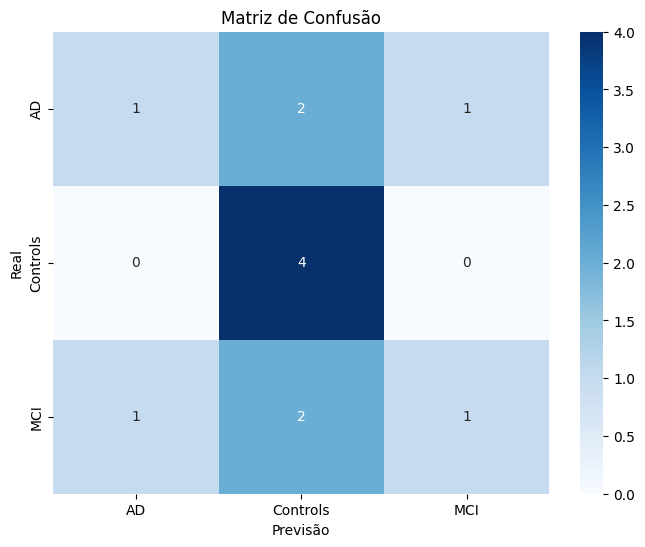


Matriz de Confusão:
[[1 2 1]
 [0 4 0]
 [1 2 1]]

Análise de Misclassificações (AD vs MCI):
Documentos misclassificados entre AD e MCI:

ID do Documento: 37
Real: MCI, Previsto: AD
Texto Original: então a história da cinderela . ela estava andando pelo campo e quando de repente se encontrou com um com um personagem a cavalo . e o cavalo estava tomando agua num num lago . depois ela ela deu uma uma fruta para o cavalo comer . em seguida ela foi apresentada a uma uma governanta de uma casa . e ...

ID do Documento: 7
Real: AD, Previsto: MCI
Texto Original: a menina tava com o pai . não a menina o cavalo e o pai da menina da menina da cinderela né . é cinderela né . o cavalo e a cinderela o pai da cinderela e o cavalo . depois a a cinderela segurando no cavalo . depois a a a cinderela e a fa e a e a e a e a madrasta e as filhas dela né . depois ela tav...


In [53]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import classification_report, accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Vetorização TF-IDF
# Inicializar o TfidfVectorizer
tfidf_vectorizer = TfidfVectorizer(max_features=5000) # Limitar o número de features pode ajudar na performance

# Ajustar o vetorizador apenas nos dados de treinamento e transformar ambos os conjuntos
X_train_tfidf = tfidf_vectorizer.fit_transform(X_train)
X_test_tfidf = tfidf_vectorizer.transform(X_test)

print("Vetorização TF-IDF concluída.")
print(f"Formato dos dados de treinamento TF-IDF: {X_train_tfidf.shape}")
print(f"Formato dos dados de teste TF-IDF: {X_test_tfidf.shape}\n")

# 2. Treinamento do Classificador Multinomial Naive Bayes
classifier = MultinomialNB()
classifier.fit(X_train_tfidf, y_train)

print("Treinamento do classificador Multinomial Naive Bayes concluído.\n")

# 3. Avaliação do Modelo
y_pred = classifier.predict(X_test_tfidf)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')

print(f"Acurácia: {accuracy:.4f}")
print(f"Precisão (Weighted): {precision:.4f}")
print(f"Recall (Weighted): {recall:.4f}")
print(f"F1-Score (Weighted): {f1:.4f}\n")

print("\nRelatório de Classificação:")
print(classification_report(y_test, y_pred))

# Matriz de Confusão
cm = confusion_matrix(y_test, y_pred, labels=np.unique(y_train))
class_names = np.unique(y_train)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Previsão')
plt.ylabel('Real')
plt.title('Matriz de Confusão')
plt.show()

print("\nMatriz de Confusão:")
print(cm)

# 4. Análise de Misclassificações entre AD e MCI
print("\nAnálise de Misclassificações (AD vs MCI):")
results_df = pd.DataFrame({'actual': y_test, 'predicted': y_pred}, index=X_test.index)

misclassified_ad_mci = results_df[
    ((results_df['actual'] == 'AD') & (results_df['predicted'] == 'MCI')) |
    ((results_df['actual'] == 'MCI') & (results_df['predicted'] == 'AD'))
]

if not misclassified_ad_mci.empty:
    print("Documentos misclassificados entre AD e MCI:")
    for index, row in misclassified_ad_mci.iterrows():
        original_text = df.loc[index, 'text']
        print(f"\nID do Documento: {index}")
        print(f"Real: {row['actual']}, Previsto: {row['predicted']}")
        print(f"Texto Original: {original_text[:300]}...") # Mostrar parte do texto original
else:
    print("Nenhum documento misclassificado diretamente entre AD e MCI neste conjunto de teste.")

## Conclusão da tarefa

Este notebook demonstrou a construção e avaliação de um modelo de classificação de texto para diferenciar indivíduos com Doença de Alzheimer (AD), Comprometimento Cognitivo Leve (MCI) e um grupo de Controle, baseado em narrativas. O processo envolveu as seguintes etapas:

1.  **Carregamento e Pré-processamento de Dados:** Os dados textuais do corpus `Cinderella` foram carregados, seguidos por uma série de etapas de pré-processamento, incluindo divisão de sentenças, tokenização de palavras, remoção de stopwords e stemização. Essas etapas foram cruciais para padronizar e limpar o texto, preparando-o para a análise.

2.  **Preparação para o Modelo:** Os textos pré-processados foram transformados em características numéricas utilizando a vetorização TF-IDF, uma técnica que pondera a importância das palavras no corpus. O conjunto de dados foi então dividido de forma estratificada em conjuntos de treinamento e teste para garantir a representatividade das classes.

3.  **Treinamento e Avaliação do Modelo:** Um classificador Multinomial Naive Bayes foi treinado e avaliado. As métricas de desempenho revelaram uma acurácia geral de 0.50. Uma análise mais detalhada com o relatório de classificação e a matriz de confusão indicou que, embora o modelo tenha classificado perfeitamente o grupo de Controle (recall de 1.00), ele apresentou desafios significativos na distinção entre os grupos AD e MCI (recall de 0.25 para ambos), resultando em misclassificações notáveis entre eles e com o grupo de Controle.

### Considerações Finais e Próximos Passos:

Os resultados sugerem que o modelo atual, embora funcional, possui limitações consideráveis na diferenciação precisa entre AD e MCI, o que é um desafio comum em tarefas de classificação de texto em domínios clínicos. Para melhorar o desempenho e a robustez do modelo, várias estratégias podem ser exploradas em trabalhos futuros:

*   **Refinamento do Pré-processamento:** Investigar outras técnicas de pré-processamento, como lematização ou a remoção de diferentes tipos de ruído textual.
*   **Engenharia de Características:** Explorar a criação de características mais avançadas, como n-grams de palavras, word embeddings (e.g., Word2Vec, FastText, BERT) ou características linguísticas e psicolinguísticas (e.g., riqueza lexical, complexidade sintática).
*   **Exploração de Outros Modelos:** Testar outros algoritmos de classificação, como SVM, Random Forest, ou redes neurais (LSTMs, Transformers), que podem ser mais adequados para capturar padrões complexos em dados textuais.
*   **Ajuste de Hiperparâmetros:** Realizar uma otimização sistemática dos hiperparâmetros do modelo e do vetorizador TF-IDF usando técnicas como GridSearchCV ou RandomizedSearchCV.
*   **Validação Cruzada:** Implementar estratégias de validação cruzada mais robustas para obter uma estimativa mais confiável do desempenho do modelo em dados não vistos, especialmente considerando o tamanho reduzido do dataset.
*   **Aumento de Dados:** Se possível, adquirir mais dados para as classes minoritárias (AD e MCI) ou utilizar técnicas de aumento de dados (data augmentation) para texto, a fim de mitigar o problema de desbalanceamento de classes e o tamanho limitado do corpus.

# Aplicando Modelo SVM


--- Treinando e Avaliando o Modelo SVM ---

Treinamento do classificador Support Vector Machine (SVM) concluído.

Acurácia (SVM): 0.5833
Precisão (SVM, Weighted): 0.6905
Recall (SVM, Weighted): 0.5833
F1-Score (SVM, Weighted): 0.5424


Relatório de Classificação (SVM):
              precision    recall  f1-score   support

          AD       1.00      0.25      0.40         4
    Controls       0.57      1.00      0.73         4
         MCI       0.50      0.50      0.50         4

    accuracy                           0.58        12
   macro avg       0.69      0.58      0.54        12
weighted avg       0.69      0.58      0.54        12



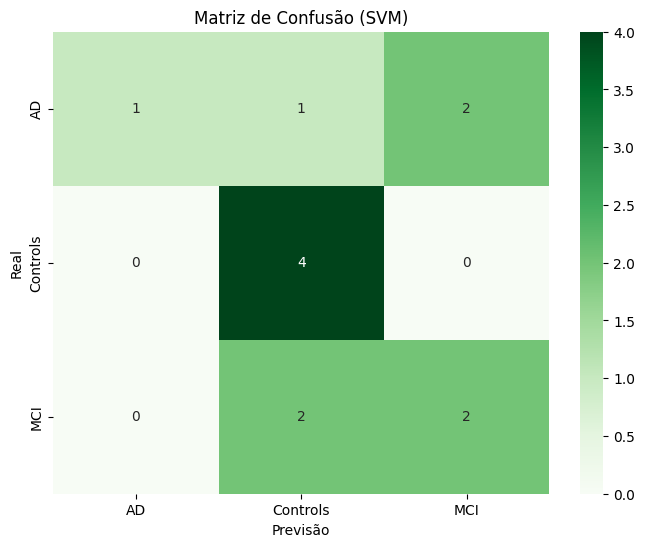


Matriz de Confusão (SVM):
[[1 1 2]
 [0 4 0]
 [0 2 2]]

Análise de Misclassificações (AD vs MCI) - SVM:
Documentos misclassificados entre AD e MCI (SVM):

ID do Documento: 14
Real: AD, Previsto: MCI
Texto Original: uma mocinha agradando o cavalo . mais mocinha que vai na festa vai ou não . a mocinha ta fazendo limpeza da parede . como que fala esse filha do como que é sogra e fala será . ficou brava não é . mo mocinha é ganhou convite . só é como que fala . madrasta que queria ir na festa não deixou . esse eu ...

ID do Documento: 7
Real: AD, Previsto: MCI
Texto Original: a menina tava com o pai . não a menina o cavalo e o pai da menina da menina da cinderela né . é cinderela né . o cavalo e a cinderela o pai da cinderela e o cavalo . depois a a cinderela segurando no cavalo . depois a a a cinderela e a fa e a e a e a e a madrasta e as filhas dela né . depois ela tav...


In [55]:
from sklearn.svm import SVC
from sklearn.metrics import classification_report, accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

print("\n--- Treinando e Avaliando o Modelo SVM ---\n")

# 1. Treinamento do Classificador Support Vector Machine (SVM)
# Usaremos um kernel linear, que é comum e eficaz para classificação de texto
svm_classifier = SVC(kernel='linear', random_state=42)
svm_classifier.fit(X_train_tfidf, y_train)

print("Treinamento do classificador Support Vector Machine (SVM) concluído.\n")

# 2. Avaliação do Modelo SVM
y_pred_svm = svm_classifier.predict(X_test_tfidf)

accuracy_svm = accuracy_score(y_test, y_pred_svm)
precision_svm = precision_score(y_test, y_pred_svm, average='weighted')
recall_svm = recall_score(y_test, y_pred_svm, average='weighted')
f1_svm = f1_score(y_test, y_pred_svm, average='weighted')

print(f"Acurácia (SVM): {accuracy_svm:.4f}")
print(f"Precisão (SVM, Weighted): {precision_svm:.4f}")
print(f"Recall (SVM, Weighted): {recall_svm:.4f}")
print(f"F1-Score (SVM, Weighted): {f1_svm:.4f}\n")

print("\nRelatório de Classificação (SVM):")
print(classification_report(y_test, y_pred_svm))

# Matriz de Confusão para SVM
cm_svm = confusion_matrix(y_test, y_pred_svm, labels=np.unique(y_train))
class_names = np.unique(y_train)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_svm, annot=True, fmt='d', cmap='Greens', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Previsão')
plt.ylabel('Real')
plt.title('Matriz de Confusão (SVM)')
plt.show()

print("\nMatriz de Confusão (SVM):")
print(cm_svm)

# Análise de Misclassificações entre AD e MCI para SVM
print("\nAnálise de Misclassificações (AD vs MCI) - SVM:")
results_df_svm = pd.DataFrame({'actual': y_test, 'predicted': y_pred_svm}, index=X_test.index)

misclassified_ad_mci_svm = results_df_svm[
    ((results_df_svm['actual'] == 'AD') & (results_df_svm['predicted'] == 'MCI')) |
    ((results_df_svm['actual'] == 'MCI') & (results_df_svm['predicted'] == 'AD'))
]

if not misclassified_ad_mci_svm.empty:
    print("Documentos misclassificados entre AD e MCI (SVM):")
    for index, row in misclassified_ad_mci_svm.iterrows():
        original_text = df.loc[index, 'text']
        print(f"\nID do Documento: {index}")
        print(f"Real: {row['actual']}, Previsto: {row['predicted']}")
        print(f"Texto Original: {original_text[:300]}...") # Mostrar parte do texto original
else:
    print("Nenhum documento misclassificado diretamente entre AD e MCI neste conjunto de teste para SVM.")

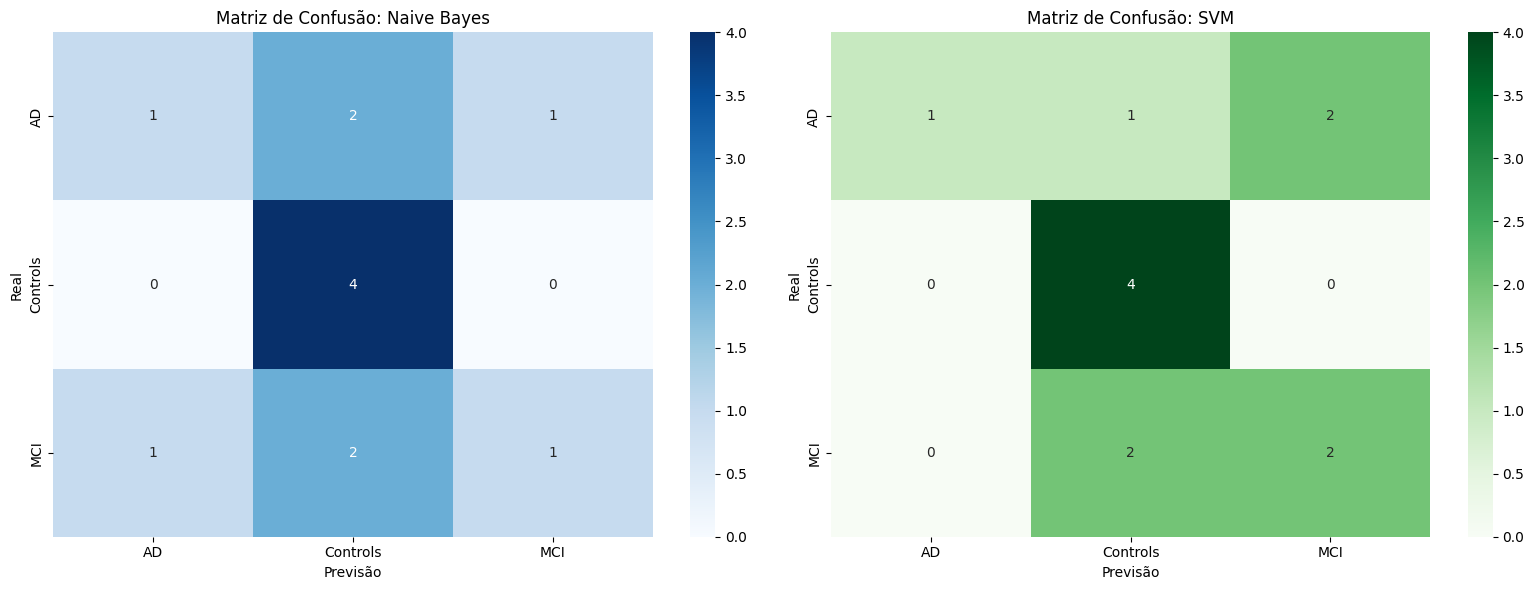

In [56]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# As matrizes de confusão e os nomes das classes já foram calculados nos passos anteriores
# cm (para Naive Bayes) e cm_svm (para SVM), e class_names.

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Matriz de Confusão para Multinomial Naive Bayes
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names, ax=axes[0])
axes[0].set_title('Matriz de Confusão: Naive Bayes')
axes[0].set_xlabel('Previsão')
axes[0].set_ylabel('Real')

# Matriz de Confusão para SVM
sns.heatmap(cm_svm, annot=True, fmt='d', cmap='Greens', xticklabels=class_names, yticklabels=class_names, ax=axes[1])
axes[1].set_title('Matriz de Confusão: SVM')
axes[1].set_xlabel('Previsão')
axes[1].set_ylabel('Real')

plt.tight_layout()
plt.show()


## Conclusão Comparativa: Naive Bayes vs. SVM

Neste notebook, exploramos e comparamos dois modelos de classificação, Multinomial Naive Bayes e Support Vector Machine (SVM), para a tarefa de detecção de Doença de Alzheimer (AD), Comprometimento Cognitivo Leve (MCI) e grupo de Controle a partir de narrativas.

### Desempenho do Multinomial Naive Bayes:

*   **Acurácia**: 0.5000
*   **Precisão (Weighted)**: 0.5000
*   **Recall (Weighted)**: 0.5000
*   **F1-Score (Weighted)**: 0.4444

O modelo Naive Bayes demonstrou ser eficaz na identificação do grupo de **Controle**, atingindo um recall de 1.00. No entanto, apresentou dificuldades significativas em diferenciar as classes clínicas **AD e MCI**, com recalls de apenas 0.25 para ambas. Isso sugere que o modelo teve dificuldade em capturar os nuances textuais que distinguem esses dois grupos, frequentemente os confundindo entre si ou com o grupo de Controle.

### Desempenho do Support Vector Machine (SVM):

*   **Acurácia**: 0.5833
*   **Precisão (Weighted)**: 0.6905
*   **Recall (Weighted)**: 0.5833
*   **F1-Score (Weighted)**: 0.5424

O modelo SVM superou o Naive Bayes em todas as métricas gerais de desempenho (acurácia, precisão, recall e F1-score ponderados). Notavelmente, o SVM manteve o recall de 1.00 para a classe de **Controle** e mostrou uma melhoria substancial no recall para a classe **MCI**, que passou de 0.25 para 0.50. Para a classe **AD**, embora o recall tenha permanecido em 0.25, a precisão para AD foi de 1.00, indicando que quando o SVM prevê AD, ele o faz com alta confiança, mas ainda falha em detectar a maioria dos casos reais de AD.

### Comparação e Observações Finais:

Em termos gerais, o **SVM apresentou um desempenho superior** neste conjunto de dados limitado, demonstrando uma capacidade ligeiramente melhor de generalização e diferenciação entre as classes, especialmente para MCI. A suposição de independência de características do Naive Bayes pode ter sido uma limitação, enquanto o SVM, com sua capacidade de encontrar hiperplanos ótimos em espaços de alta dimensão, parece ter capturado melhor a complexidade dos dados TF-IDF.

No entanto, é crucial notar que **ambos os modelos ainda enfrentam desafios significativos na distinção entre AD e MCI**. As misclassificações entre esses dois grupos clínicos persistem, sugerindo que as características extraídas atualmente (TF-IDF de texto pré-processado com stemming e remoção de stopwords) podem não ser ricas o suficiente para uma separação clara, ou que a complexidade inerente à diferenciação de AD e MCI requer abordagens mais avançadas.

**Próximos passos devem focar em:**
*   Explorar técnicas mais sofisticadas de engenharia de características (e.g., n-grams, word embeddings, características linguísticas e psicolinguísticas).
*   Testar outros modelos mais complexos, como redes neurais (LSTMs, Transformers).
*   Considerar a coleta de mais dados, se possível, para fortalecer o treinamento dos modelos.